
# Actividad 3: Clasificación visual reproducible con una CNN



## Estudiantes:
- Luis Jorge García
- Luis Eduardo Uribe
- Felipe Barreto Patiño


##### **Proyecto propio:** (ver `README.md`). Las imágenes son frames de video de pádel grabado por el autor.

- los 5 keypoints por jugador (cabeza, hombro, codo, muñeca, raqueta) fueron **anotados manualmente** vía Roboflow y exportados en formato YOLO-pose. El dataset (`data/Padel_an_2-6/`) se descarga directamente desde Roboflow en el Checkpoint 0.5 de este notebook.

##### **Este notebook aborda dos tareas:**

1. **Predicción de los 5 keypoints por jugador** (regresión de coordenadas), comparando tres enfoques de modelado: una **CNN propia** entrenada desde cero, **transfer learning** (backbone preentrenado + cabeza de regresión) y el detector **YOLO-pose** (ultralytics) ya entrenado en `notebooks/actividad_3b_yolo_pose_deteccion.ipynb`. Es la base de "trackear correctamente los 5 puntos de cada jugador" en video (ver `notebooks/actividad_3c_demo_inferencia_video.ipynb`, que agrega tracking con identidad
   persistente por jugador).
2. **Clasificación del tipo de keypoint** (cabeza/hombro/codo/muñeca/raqueta) a partir de un recorte pequeño centrado en cada punto anotado: esto produce una salida de clasificación con matriz de confusión y métricas por clase.

Cada sección es un *checkpoint*: se ejecuta y deja su resultado (tabla, gráfica o print) visible antes de continuar con el siguiente paso.


## Checkpoint 0: Imports y configuración

In [1]:

import os, re, json, random, glob, math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_repo_root(start=None):
    p = Path(start or Path.cwd())
    for _ in range(5):
        if (p / "data.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("No se encontró data.yaml subiendo desde " + str(start))

ROOT = find_repo_root()
PROC = ROOT / "data" / "processed"
DATA_DIR = ROOT / "data" / "Padel_an_2-6"  # dataset limpio (ver Checkpoint 0.5)
# Código original: solo contemplaba CUDA o CPU.
# device = "cuda" if torch.cuda.is_available() else "cpu"
# Cambio para priorizar CUDA, luego MPS en Apple Silicon y finalmente CPU.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("Device:", device)

KP_NAMES = ["hombro", "codo", "muneca", "raqueta", "cabeza"]  # ver Checkpoint 0.6: orden real verificado visualmente


ROOT: /Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection
DATA_DIR: /Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/data/Padel_an_2-6
Device: mps



## Checkpoint 0.5: Origen de los datos: reexportación limpia desde Roboflow

Un primer export de este proyecto (formato YOLO-pose "nativo" de Roboflow) tenía un **bug de
exportación**, donde veíamos hombro-X, codo-Y y raqueta-X con un valor centinela `2.0` (fuera de rango) en la mayoría de las instancias - verificado comparando ambos exports valor por valor, los números de la versión rota eran los mismos de la buena pero desplazados entre ejes/keypoints. No era un problema de la anotación manual (se confirmó revisando directamente en Roboflow).

Reexportando con `download("yolov5")` los 15 valores de keypoints salen **completos y correctos** (`v=2` cuando están etiquetados, `v=0` genuino cuando no, sin centinelas) - verificado sobre las 1150 instancias × 5 keypoints × 2 ejes: 0 valores fuera de rango. 

Esta celda descarga esa versión a `data/Padel_an_2-6/`, que es el dataset que usa el resto del notebook (`DATA_DIR`).

Las imágenes (`*.jpg`) están en `.gitignore` (no se suben a git, solo los `.txt` de labels), así que en un clon nuevo del repo la carpeta puede "existir" con los labels pero sin fotos - por eso el chequeo de abajo mira si hay imágenes reales, no solo si la carpeta existe.



In [2]:

from roboflow import Roboflow

def _has_any_jpg(d):
    return next(d.glob("*.jpg"), None) is not None

has_images = any(_has_any_jpg(DATA_DIR / s / "images") for s in ["train", "valid", "test"])
if not has_images:
    api_key = os.environ.get("ROBOFLOW_API_KEY", "zNw65fEZW3sa0KfRJRzI")
    rf = Roboflow(api_key=api_key)
    project = rf.workspace("padel1s-workspace").project("padel_an_2")
    version = project.version(6)
    version.download("yolov5", location=str(DATA_DIR), overwrite=True)
    print("Dataset descargado en:", DATA_DIR)
else:
    print("Dataset ya presente en:", DATA_DIR)


Dataset ya presente en: /Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/data/Padel_an_2-6



## Checkpoint 0.6: Orden real de los 5 keypoints con verificación visual

`data.yaml` no documenta a qué parte del cuerpo corresponde cada uno de los 5 keypoints - solo dice `kpt_shape: [5, 3]`. 

Anteriormente, se había asumido el orden **cabeza, hombro, codo, muñeca, raqueta** (índices 0-4) tal como se describió el proyecto, pero al revisar las imágenes anotadas el orden real resultó **desplazado en uno**. 

El índice 0 es en realidad el hombro, no la cabeza. Verificado dibujando los 5 puntos sobre la instancia con el bbox más grande del dataset (jugador más cerca de cámara, para que la posición de cada punto se vea sin ambigüedad) y confirmando a simple vista contra la foto.

Orden correcto por índice: `0=hombro, 1=codo, 2=muñeca, 3=raqueta, 4=cabeza`.


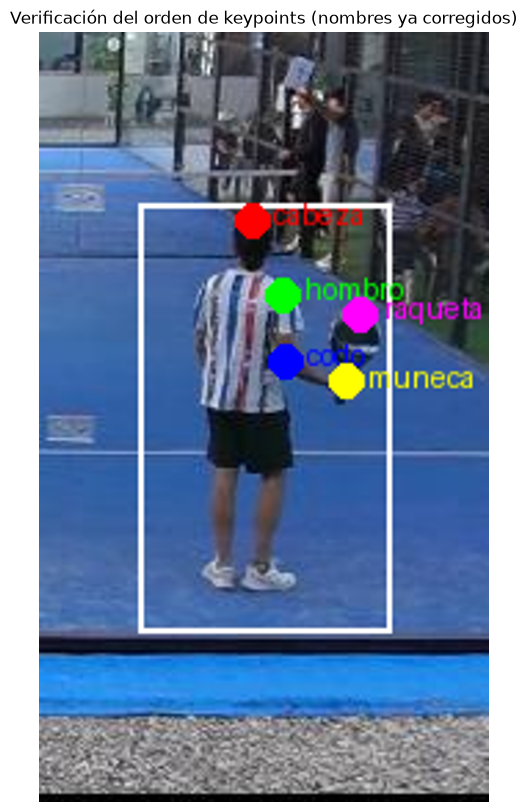

In [3]:

# Verificación visual: instancia con el bbox más grande (jugador más cerca de cámara)
def _largest_instance():
    best = None
    for orig_split in ["train", "valid", "test"]:
        lbl_dir = DATA_DIR / orig_split / "labels"
        for lf in lbl_dir.glob("*.txt"):
            for cx, cy, w, h, kpts in parse_label_file_preview(lf):
                if best is None or h > best[0]:
                    img_path = DATA_DIR / orig_split / "images" / (lf.stem + ".jpg")
                    best = (h, img_path, (cx, cy, w, h), kpts)
    return best

def parse_label_file_preview(path):
    persons = []
    with open(path) as f:
        for line in f:
            tok = line.strip().split()
            if not tok:
                continue
            vals = list(map(float, tok))
            cx, cy, w, h = vals[1:5]
            persons.append((cx, cy, w, h, vals[5:20]))
    return persons

_, img_path, (cx, cy, w, h), kpts = _largest_instance()
im = Image.open(img_path).convert("RGB")
W, H = im.size
draw = ImageDraw.Draw(im)
COLORS = [(0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (255, 0, 0)]
draw.rectangle([(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H], outline=(255, 255, 255), width=2)
for i in range(5):
    x, y = kpts[3*i], kpts[3*i+1]
    px, py = x*W, y*H
    draw.ellipse([px-6, py-6, px+6, py+6], fill=COLORS[i])
    draw.text((px+8, py-8), KP_NAMES[i], fill=COLORS[i])

m = 0.4
box = (max(0, (cx-w/2-m*w)*W), max(0, (cy-h/2-m*h)*H), min(W, (cx+w/2+m*w)*W), min(H, (cy+h/2+m*h)*H))
crop = im.crop(tuple(map(int, box)))
crop = crop.resize((crop.width*3, crop.height*3))
plt.figure(figsize=(6, 10))
plt.imshow(crop)
plt.axis("off")
plt.title("Verificación del orden de keypoints (nombres ya corregidos)")
plt.show()



## Checkpoint 1: EDA y parsing de las anotaciones de pose

Cada línea de un `.txt` (formato YOLO-pose) trae, por jugador: `clase cx cy w h` (bbox normalizado) seguido de 5 keypoints × (x, y, visibilidad) en el orden **hombro, codo, muñeca, raqueta, cabeza**

Juntamos las imágenes de los tres folders originales de Roboflow en un solo pool, porque ese split mezcla frames del mismo rally entre particiones (fuga de información) - lo rehacemos en el Checkpoint 2.


In [4]:

RALLY_RE = re.compile(r"^(.*_mp4)-(\d+)_jpg")

def parse_label_file(path):
    persons = []
    with open(path) as f:
        for line in f:
            tok = line.strip().split()
            if not tok:
                continue
            vals = list(map(float, tok))
            cx, cy, w, h = vals[1:5]
            kpts = vals[5:20]
            persons.append((cx, cy, w, h, kpts))
    return persons

rows = []
for orig_split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / orig_split / "images"
    lbl_dir = DATA_DIR / orig_split / "labels"
    for img_path in sorted(img_dir.glob("*.jpg")):
        stem = img_path.stem
        lbl_path = lbl_dir / (stem + ".txt")
        m = RALLY_RE.match(img_path.name)
        rally_id = m.group(1) if m else "unknown"
        if not lbl_path.exists():
            continue
        for idx, (cx, cy, w, h, kpts) in enumerate(parse_label_file(lbl_path)):
            rows.append(dict(image_id=stem, image_path=str(img_path), rally_id=rally_id,
                              person_idx=idx, cx=cx, cy=cy, w=w, h=h, kpts=kpts))

df = pd.DataFrame(rows)
print(f"Imágenes con >=1 jugador anotado: {df['image_id'].nunique()}")
print(f"Instancias de jugador (filas): {len(df)}")
print(f"Rallies distintos: {df['rally_id'].nunique()}")


Imágenes con >=1 jugador anotado: 333
Instancias de jugador (filas): 1150
Rallies distintos: 35


## Checkpoint 2: Re-partición por rally

División train/valid/test sin fuga entre rallies, con semilla fija (42).

In [5]:

splits_path = PROC / "image_splits.csv"
if splits_path.exists():
    splits = pd.read_csv(splits_path)
    print("Reutilizando partición existente:", splits_path)
else:
    images_df = df.drop_duplicates("image_id")[["image_id", "rally_id"]].reset_index(drop=True)
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    train_idx, temp_idx = next(gss1.split(images_df, groups=images_df["rally_id"]))
    temp_df = images_df.iloc[temp_idx]
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
    valid_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["rally_id"]))
    split_map = {}
    for i in train_idx: split_map[images_df.iloc[i]["image_id"]] = "train"
    for i in valid_idx: split_map[temp_df.iloc[i]["image_id"]] = "valid"
    for i in test_idx: split_map[temp_df.iloc[i]["image_id"]] = "test"
    images_df["split"] = images_df["image_id"].map(split_map)
    splits = images_df[["image_id", "rally_id", "split"]]
    PROC.mkdir(parents=True, exist_ok=True)
    splits.to_csv(splits_path, index=False)
    print("Partición nueva guardada en:", splits_path)

split_map = dict(zip(splits.image_id, splits.split))
df["split"] = df["image_id"].map(split_map)
assert df["split"].notna().all(), "Hay imágenes sin split asignado"

rally_splits = df.groupby("rally_id")["split"].nunique()
assert (rally_splits == 1).all(), "¡Fuga detectada! Un rally aparece en más de un split."
print("OK: cada rally cae en un único split.\n")
print("Imágenes por split:")
print(df.drop_duplicates("image_id").groupby("split").size())
print("\nInstancias (jugadores) por split:")
print(df.groupby("split").size())


Reutilizando partición existente: /Users/psychobolt/Documents/education/universidad_de_la_sabana/maestria_en_inteligencia_artificial/asignaturas/TAIA/unidad_2/padel-impact-position-detection/data/processed/image_splits.csv
OK: cada rally cae en un único split.

Imágenes por split:
split
test      64
train    204
valid     65
dtype: int64

Instancias (jugadores) por split:
split
test     221
train    682
valid    247
dtype: int64



## Checkpoint 3: Validez por keypoint (bandera de visibilidad)

Con el export corregido (Checkpoint 0.5), la bandera de visibilidad `v` de cada keypoint ya es
significativa: `v=2`, `v=0`. 

Se usa directamente `v>0` como máscara de validez por keypoint. 

La fracción de "no etiquetado" es baja y pareja entre los 5 puntos (0.1%-7.7%).

Para los pocos keypoints no etiquetados se sustituye la posición por el centro del bbox de la persona y se guarda la máscara de validez, que se usa para: 

- No penalizar a los modelos por keypoints sin dato real durante el entrenamiento.
- No contarlos en las métricas de error.


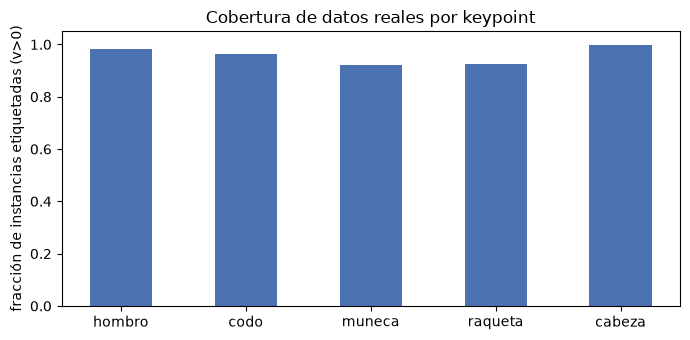

In [6]:

def process_kpts(row):
    kpts = row["kpts"]
    cx, cy = row["cx"], row["cy"]
    out, mask = [], []
    for i in range(5):
        x, y, v = kpts[3 * i], kpts[3 * i + 1], kpts[3 * i + 2]
        valid = v > 0
        out.append(x if valid else cx)
        out.append(y if valid else cy)
        mask.append(1.0 if valid else 0.0)
        mask.append(1.0 if valid else 0.0)
    return pd.Series({**{f"kp_{i}": v for i, v in enumerate(out)},
                       **{f"mask_{i}": v for i, v in enumerate(mask)}})

kp_df = df.apply(process_kpts, axis=1)
df = pd.concat([df.reset_index(drop=True), kp_df.reset_index(drop=True)], axis=1)

fig, ax = plt.subplots(figsize=(7, 3.5))
cov = [df[f"mask_{2*i}"].mean() for i in range(5)]
xpos = np.arange(5)
ax.bar(xpos, cov, width=0.5, color="#4C72B0")
ax.set_xticks(xpos); ax.set_xticklabels(KP_NAMES)
ax.set_ylim(0, 1.05)
ax.set_ylabel("fracción de instancias etiquetadas (v>0)")
ax.set_title("Cobertura de datos reales por keypoint")
plt.tight_layout()
plt.show()



## Checkpoint 4: Visualización del etiquetado (ground truth)

Se dibuja el esqueleto anotado sobre imágenes de ejemplo: puntos/ejes con dato real en **verde sólido**,
puntos con algún eje sustituido (aproximado por el centro del bbox) en **naranja con borde punteado**.


Etiquetado ground-truth: verde=dato real, naranja punteado=eje aproximado (bbox center).
Un color de esqueleto distinto por cada jugador de la imagen (hasta 4).


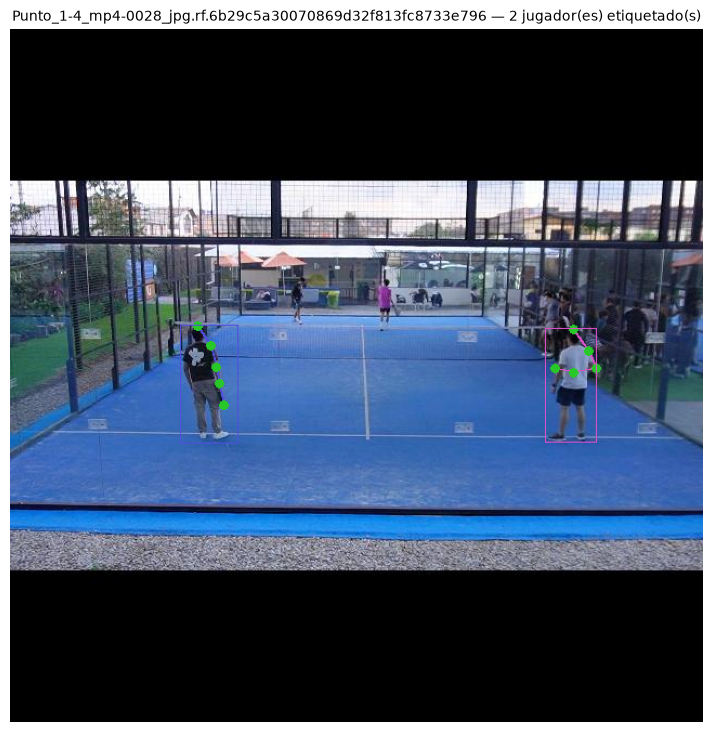

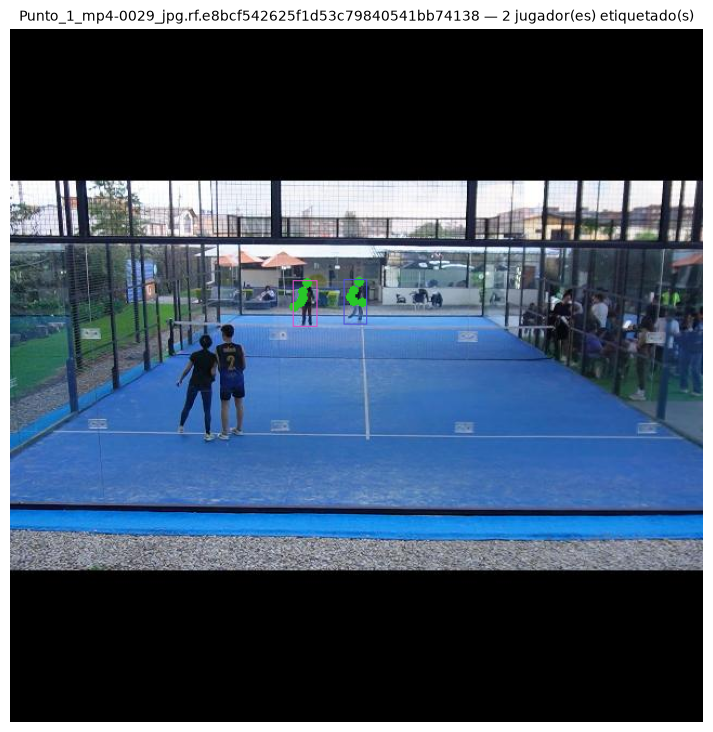

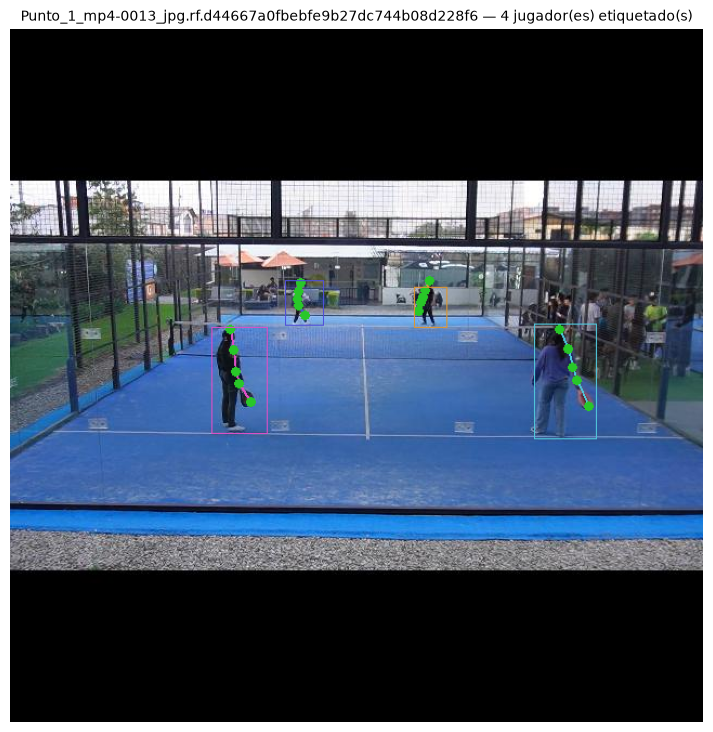

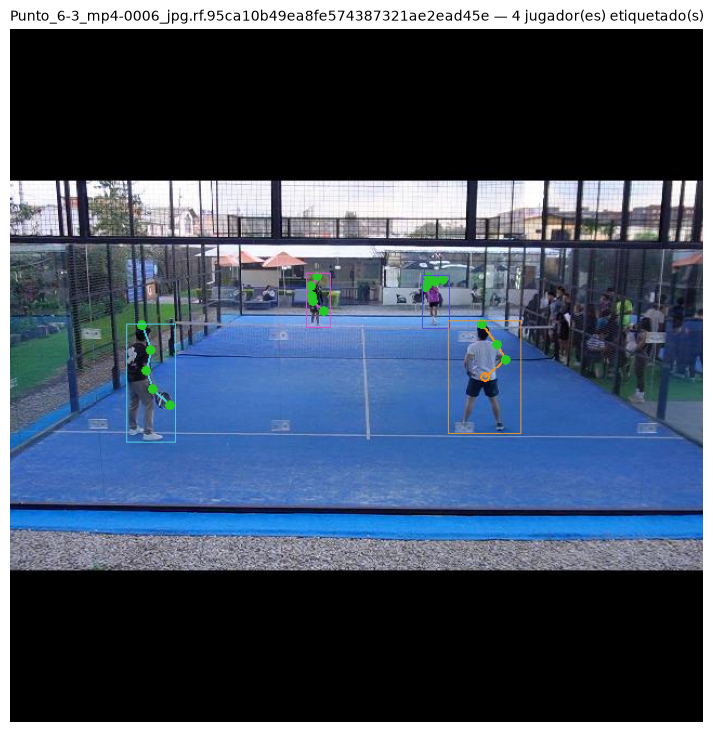

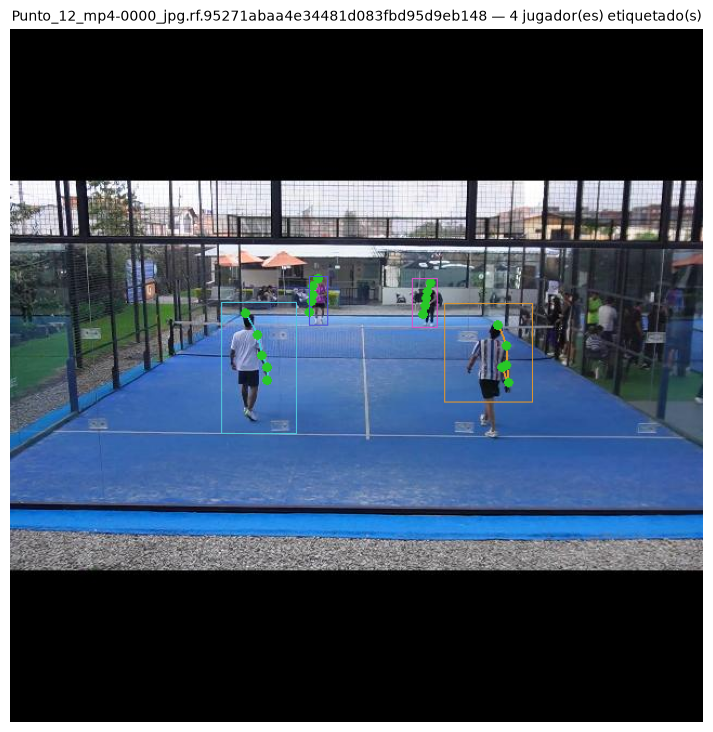

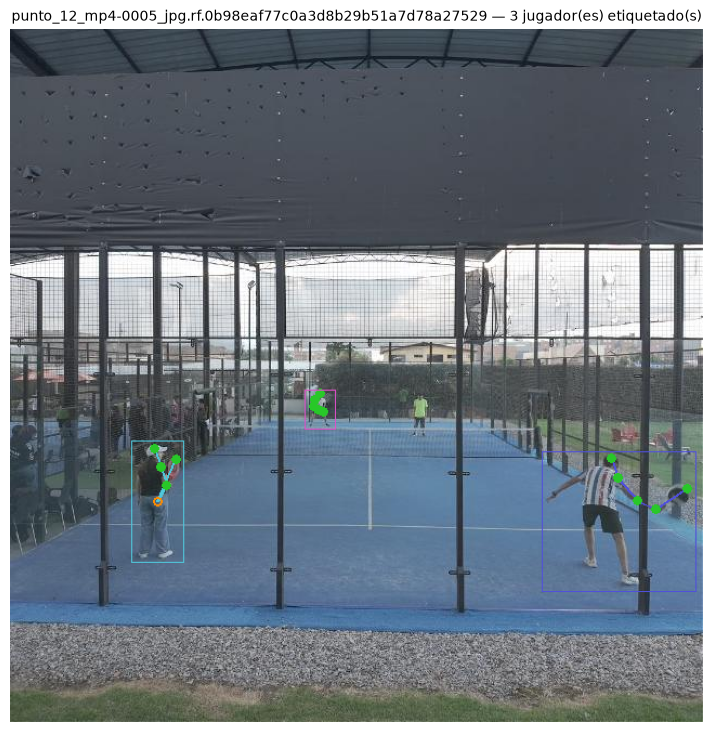

In [7]:

SKELETON_COLORS = [(80,80,220), (220,80,200), (80,200,220), (220,150,50)]  # una por jugador (hasta 4)

def draw_person(draw, W, H, kxy, mask, line_color, box=None,
                 color_ok=(40,200,40), color_bad=(255,140,0), radius=4):
    pts = []
    for i in range(5):
        x, y = kxy[2*i]*W, kxy[2*i+1]*H
        ok = mask[2*i] > 0 and mask[2*i+1] > 0
        pts.append((x, y, ok))
    SKELETON = [(4,0),(0,1),(1,2),(2,3)]  # cabeza(4)-hombro(0)-codo(1)-muneca(2)-raqueta(3)
    for a, b in SKELETON:
        draw.line([pts[a][0], pts[a][1], pts[b][0], pts[b][1]], fill=line_color, width=2)
    for (x, y, ok) in pts:
        c = color_ok if ok else color_bad
        if ok:
            draw.ellipse([x-radius, y-radius, x+radius, y+radius], fill=c, outline=c)
        else:
            draw.ellipse([x-radius, y-radius, x+radius, y+radius], outline=c, width=2)
    if box is not None:
        cx, cy, w, h = box
        draw.rectangle([(cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H], outline=line_color, width=1)

print("Etiquetado ground-truth: verde=dato real, naranja punteado=eje aproximado (bbox center).")
print("Un color de esqueleto distinto por cada jugador de la imagen (hasta 4).")

sample_images = df.drop_duplicates("image_id").sample(6, random_state=SEED)["image_id"]
img_cache = {}
for image_id in sample_images:
    persons = df[df.image_id == image_id]
    image_path = persons.iloc[0].image_path
    if image_path not in img_cache:
        img_cache[image_path] = Image.open(image_path).convert("RGB")
    im_annot = img_cache[image_path].copy()
    draw = ImageDraw.Draw(im_annot)
    W, H = im_annot.size
    for _, r in persons.iterrows():
        kxy = [r[f"kp_{i}"] for i in range(10)]
        mask = [r[f"mask_{i}"] for i in range(10)]
        color = SKELETON_COLORS[r.person_idx % len(SKELETON_COLORS)]
        draw_person(draw, W, H, kxy, mask, color, box=(r.cx, r.cy, r.w, r.h))

    plt.figure(figsize=(9, 9))
    plt.imshow(im_annot)
    plt.title(f"{image_id} — {len(persons)} jugador(es) etiquetado(s)", fontsize=10)
    plt.axis("off")
    plt.show()



## Checkpoint 5: Recortes con targets de keypoints (crop-relative)

Acá con el export corregido, logramos que los 5 keypoints caigan casi siempre dentro (o muy cerca) del bbox de la persona.

Esta afirmación se comprobó sobre las 1150 instancias, con un padding de 0.25x el ancho/alto del bbox a los lados y arriba, y 0.35x hacia abajo (para la raqueta, que a veces se extiende un poco más abajo de la mano), la cobertura es >99.5% en los 5 puntos. Es un padding mucho más chico que el que hacía falta con el export roto (que llegaba a 1.5x-3.3x para intentar capturar puntos que en realidad eran ruido de exportación). 

Cada keypoint se re-expresa en coordenadas **relativas al recorte** (0-1), y la máscara final combina la visibilidad (`v>0`) **y** que el punto caiga dentro del recorte.


In [8]:

CROPS_DIR = PROC / "crops_kpts"
PAD_TOP_FRAC, PAD_BOTTOM_FRAC, PAD_X_FRAC = 0.25, 0.35, 0.25

img_cache = {}
rows_m = []
for _, r in df.iterrows():
    if r.image_path not in img_cache:
        img_cache[r.image_path] = Image.open(r.image_path).convert("RGB")
    im = img_cache[r.image_path]
    W, H = im.size

    bbox_top_px = (r.cy - r.h/2) * H
    bbox_bot_px = (r.cy + r.h/2) * H
    bbox_left_px = (r.cx - r.w/2) * W
    bbox_right_px = (r.cx + r.w/2) * W
    bbox_h_px, bbox_w_px = r.h*H, r.w*W

    top = max(0, bbox_top_px - PAD_TOP_FRAC*bbox_h_px)
    bottom = min(H, bbox_bot_px + PAD_BOTTOM_FRAC*bbox_h_px)
    left = max(0, bbox_left_px - PAD_X_FRAC*bbox_w_px)
    right = min(W, bbox_right_px + PAD_X_FRAC*bbox_w_px)

    crop = im.crop((int(left), int(top), int(right), int(bottom)))
    out_dir = CROPS_DIR / r.split
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{r.image_id}_p{r.person_idx}.jpg"
    crop.save(out_path, quality=90)

    cw, ch = right-left, bottom-top
    kp_crop, mask_final = [], []
    for i in range(5):
        x_px, y_px = r[f"kp_{2*i}"]*W, r[f"kp_{2*i+1}"]*H
        cxr, cyr = (x_px-left)/cw, (y_px-top)/ch
        in_bounds = 0 <= cxr <= 1 and 0 <= cyr <= 1
        kp_crop += [np.clip(cxr,0,1), np.clip(cyr,0,1)]
        mask_final += [r[f"mask_{2*i}"] if in_bounds else 0.0,
                        r[f"mask_{2*i+1}"] if in_bounds else 0.0]

    row = dict(image_id=r.image_id, person_idx=r.person_idx, rally_id=r.rally_id, split=r.split,
               crop_path=str(out_path), crop_left=left, crop_top=top, crop_right=right, crop_bottom=bottom,
               cx=r.cx, cy=r.cy, w=r.w, h=r.h)
    for i in range(10):
        row[f"kp_{i}"] = kp_crop[i]
        row[f"mask_{i}"] = mask_final[i]
    rows_m.append(row)

manifest = pd.DataFrame(rows_m)
manifest.to_csv(PROC / "manifest_keypoints.csv", index=False)
print("Crops generados:", len(manifest))
print("\nCobertura final por keypoint (válido en dato crudo Y dentro del recorte):")
for i, n in enumerate(KP_NAMES):
    print(f"  {n}: x={manifest[f'mask_{2*i}'].mean():.3f}  y={manifest[f'mask_{2*i+1}'].mean():.3f}")


Crops generados: 1150

Cobertura final por keypoint (válido en dato crudo Y dentro del recorte):
  hombro: x=0.983  y=0.983
  codo: x=0.963  y=0.963
  muneca: x=0.922  y=0.922
  raqueta: x=0.919  y=0.919
  cabeza: x=0.998  y=0.998



## Checkpoint 6: Dataset / DataLoader (PyTorch)

- `Dataset` que entrega el recorte (redimensionado a 128×192), el vector de 10 valores objetivo (x,y de cada keypoint en coordenadas del recorte) y la máscara de 10 valores. 

- Augmentation: flip horizontal en train.

In [9]:

IMG_SIZE = (128, 192)  # W,H
KP_COLS = [f"kp_{i}" for i in range(10)]
MASK_COLS = [f"mask_{i}" for i in range(10)]

def load_resized(path):
    im = Image.open(path).convert("RGB").resize(IMG_SIZE, Image.BILINEAR)
    return np.asarray(im, dtype=np.float32) / 255.0

train_manifest = manifest[manifest.split == "train"].reset_index(drop=True)
sample = train_manifest.sample(min(300, len(train_manifest)), random_state=SEED)
pix = np.stack([load_resized(p) for p in sample.crop_path])
MEAN = pix.reshape(-1, 3).mean(axis=0)
STD = pix.reshape(-1, 3).std(axis=0)
print("Media (RGB, train):", MEAN)
print("Desv. estándar (RGB, train):", STD)

class KeypointDataset(Dataset):
    def __init__(self, mdf, train=False, normalize="custom"):
        self.mdf = mdf.reset_index(drop=True)
        self.train = train
        self.normalize = normalize

    def __len__(self):
        return len(self.mdf)

    def __getitem__(self, i):
        row = self.mdf.iloc[i]
        arr = load_resized(row.crop_path)
        kp = row[KP_COLS].values.astype(np.float32).copy()
        mask = row[MASK_COLS].values.astype(np.float32).copy()
        if self.train and random.random() < 0.5:
            arr = arr[:, ::-1, :].copy()
            for k in range(5):
                kp[2 * k] = 1.0 - kp[2 * k]
        if self.normalize == "custom":
            arr = (arr - MEAN) / (STD + 1e-6)
        else:  # imagenet stats, para el backbone preentrenado
            arr = (arr - np.array([0.485, 0.456, 0.406], dtype=np.float32)) / \
                  np.array([0.229, 0.224, 0.225], dtype=np.float32)
        arr = np.transpose(arr, (2, 0, 1)).astype(np.float32)
        return torch.from_numpy(arr), torch.from_numpy(kp), torch.from_numpy(mask)

def masked_smoothl1(pred, target, mask):
    diff = torch.nn.functional.smooth_l1_loss(pred, target, reduction="none") * mask
    return diff.sum() / mask.sum().clamp(min=1.0)


Media (RGB, train): [0.32180712 0.42170972 0.5741119 ]
Desv. estándar (RGB, train): [0.14061859 0.14769681 0.20653318]



## Checkpoint 7: Modelo A: CNN propia (regresión desde cero)

Misma familia de arquitectura que una CNN de clasificación básica (4 bloques Conv–BatchNorm–ReLU con MaxPool, GlobalAveragePooling), pero con una capa final `Linear(128, 10)` + `Sigmoid` (para que la salida caiga en [0,1], igual que los targets) en vez de una capa de clasificación. 

La pérdida es `SmoothL1` **enmascarada**: solo penaliza los ejes con dato real, para no enseñarle al modelo a predecir el centro del bbox como si fuera la posición verdadera de un keypoint no anotado.


In [10]:

train_loader_a = DataLoader(KeypointDataset(manifest[manifest.split=="train"], True, "custom"), batch_size=32, shuffle=True)
valid_loader_a = DataLoader(KeypointDataset(manifest[manifest.split=="valid"], False, "custom"), batch_size=32, shuffle=False)
test_loader_a  = DataLoader(KeypointDataset(manifest[manifest.split=="test"],  False, "custom"), batch_size=32, shuffle=False)

class CNNRegressor(nn.Module):
    def __init__(self, n_out=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n_out), nn.Sigmoid())

    def forward(self, x):
        return self.head(self.features(x))

model_a = CNNRegressor().to(device)
print(model_a)
print("Parámetros entrenables:", sum(p.numel() for p in model_a.parameters()))

opt_a = torch.optim.Adam(model_a.parameters(), lr=1e-3)

def run_epoch(model, opt, loader, train):
    model.train(train)
    tot, n = 0.0, 0
    for xb, kb, mb in loader:
        xb, kb, mb = xb.to(device), kb.to(device), mb.to(device)
        if train: opt.zero_grad()
        pred = model(xb)
        loss = masked_smoothl1(pred, kb, mb)
        if train:
            loss.backward(); opt.step()
        tot += loss.item() * xb.size(0); n += xb.size(0)
    return tot / n

# Código original: 25 épocas y selección del mínimo validation loss.
# EPOCHS = 25
# history_a = []
# best_val_a, best_state_a = float("inf"), None
# for ep in range(1, EPOCHS + 1):
#     tr = run_epoch(model_a, opt_a, train_loader_a, True)
#     va = run_epoch(model_a, opt_a, valid_loader_a, False)
#     history_a.append((ep, tr, va))
#     if va < best_val_a:
#         best_val_a = va
#         best_state_a = {k: v.clone() for k, v in model_a.state_dict().items()}
#     print(f"ep{ep:02d} train_loss={tr:.4f} val_loss={va:.4f}")
# model_a.load_state_dict(best_state_a)

# Cambio para aplicar Early Stopping sobre validation loss y restaurar su mínimo absoluto.
EPOCHS_A = 500
PATIENCE_A = 20
MIN_DELTA_A = 1e-4

history_a = []
best_val_a = float("inf")
best_state_a = None
best_epoch_a = None
early_stopping_reference_a = float("inf")
epochs_without_significant_improvement_a = 0

for ep in range(1, EPOCHS_A + 1):
    tr = run_epoch(model_a, opt_a, train_loader_a, True)
    va = run_epoch(model_a, opt_a, valid_loader_a, False)
    history_a.append((ep, tr, va))

    # Guardar siempre el mínimo absoluto, aunque la mejora sea menor que min_delta.
    if va < best_val_a:
        best_val_a = va
        best_epoch_a = ep
        best_state_a = {k: v.detach().cpu().clone() for k, v in model_a.state_dict().items()}

    # Referencia separada: las mejoras pequeñas pueden acumularse hasta min_delta.
    if early_stopping_reference_a - va >= MIN_DELTA_A:
        early_stopping_reference_a = va
        epochs_without_significant_improvement_a = 0
    else:
        epochs_without_significant_improvement_a += 1

    print(f"ep{ep:03d} train_loss={tr:.4f} val_loss={va:.4f}")

    if epochs_without_significant_improvement_a >= PATIENCE_A:
        print(f"Early Stopping del Modelo A activado en la época {ep}: validation loss no mejoró al menos {MIN_DELTA_A:.1e} durante {PATIENCE_A} épocas.")
        break

if best_state_a is None:
    raise RuntimeError("No se pudo guardar un estado válido del Modelo A.")
model_a.load_state_dict(best_state_a)
print(f"Modelo A — mejor época: {best_epoch_a} | Mejor validation loss: {best_val_a:.6f}")


CNNRegressor(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affin

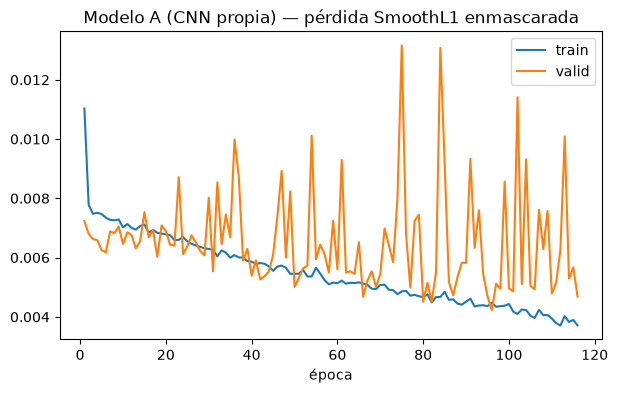

In [11]:

hist_a = pd.DataFrame(history_a, columns=["epoch", "train_loss", "val_loss"])
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(hist_a.epoch, hist_a.train_loss, label="train")
ax.plot(hist_a.epoch, hist_a.val_loss, label="valid")
ax.set_title("Modelo A (CNN propia) — pérdida SmoothL1 enmascarada")
ax.set_xlabel("época"); ax.legend()
plt.show()



## Checkpoint 8: Modelo B: Transfer learning (ResNet18 + cabeza de regresión)

Backbone `ResNet18` preentrenado en ImageNet, con todas las capas congeladas salvo el último bloque
residual (`layer4`), que se afina junto con una nueva cabeza `Linear(512, 10) + Sigmoid`. Misma pérdida
enmascarada, mismo split, mismas épocas — la única diferencia real frente al Modelo A es el uso de
características preentrenadas.


In [12]:

train_loader_b = DataLoader(KeypointDataset(manifest[manifest.split=="train"], True, "imagenet"), batch_size=32, shuffle=True)
valid_loader_b = DataLoader(KeypointDataset(manifest[manifest.split=="valid"], False, "imagenet"), batch_size=32, shuffle=False)
test_loader_b  = DataLoader(KeypointDataset(manifest[manifest.split=="test"],  False, "imagenet"), batch_size=32, shuffle=False)

backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for p in backbone.parameters():
    p.requires_grad = False
for p in backbone.layer4.parameters():
    p.requires_grad = True
backbone.fc = nn.Sequential(nn.Linear(backbone.fc.in_features, 10), nn.Sigmoid())
model_b = backbone.to(device)

trainable = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_b.parameters())
print(f"Parámetros entrenables: {trainable:,} / totales: {total:,} (resto congelado)")

opt_b = torch.optim.Adam([p for p in model_b.parameters() if p.requires_grad], lr=1e-3)

# Código original: 25 épocas y selección del mínimo validation loss.
# history_b = []
# best_val_b, best_state_b = float("inf"), None
# for ep in range(1, EPOCHS + 1):
#     tr = run_epoch(model_b, opt_b, train_loader_b, True)
#     va = run_epoch(model_b, opt_b, valid_loader_b, False)
#     history_b.append((ep, tr, va))
#     if va < best_val_b:
#         best_val_b = va
#         best_state_b = {k: v.clone() for k, v in model_b.state_dict().items()}
#     print(f"ep{ep:02d} train_loss={tr:.4f} val_loss={va:.4f}")
# model_b.load_state_dict(best_state_b)

# Cambio para aplicar Early Stopping sobre validation loss y restaurar su mínimo absoluto.
EPOCHS_B = 500
PATIENCE_B = 20
MIN_DELTA_B = 1e-4

history_b = []
best_val_b = float("inf")
best_state_b = None
best_epoch_b = None
early_stopping_reference_b = float("inf")
epochs_without_significant_improvement_b = 0

for ep in range(1, EPOCHS_B + 1):
    tr = run_epoch(model_b, opt_b, train_loader_b, True)
    va = run_epoch(model_b, opt_b, valid_loader_b, False)
    history_b.append((ep, tr, va))

    # Guardar siempre el mínimo absoluto, aunque la mejora sea menor que min_delta.
    if va < best_val_b:
        best_val_b = va
        best_epoch_b = ep
        best_state_b = {k: v.detach().cpu().clone() for k, v in model_b.state_dict().items()}

    # Referencia separada: las mejoras pequeñas pueden acumularse hasta min_delta.
    if early_stopping_reference_b - va >= MIN_DELTA_B:
        early_stopping_reference_b = va
        epochs_without_significant_improvement_b = 0
    else:
        epochs_without_significant_improvement_b += 1

    print(f"ep{ep:03d} train_loss={tr:.4f} val_loss={va:.4f}")

    if epochs_without_significant_improvement_b >= PATIENCE_B:
        print(f"Early Stopping del Modelo B activado en la época {ep}: validation loss no mejoró al menos {MIN_DELTA_B:.1e} durante {PATIENCE_B} épocas.")
        break

if best_state_b is None:
    raise RuntimeError("No se pudo guardar un estado válido del Modelo B.")
model_b.load_state_dict(best_state_b)
print(f"Modelo B — mejor época: {best_epoch_b} | Mejor validation loss: {best_val_b:.6f}")


Parámetros entrenables: 8,398,858 / totales: 11,181,642 (resto congelado)
ep001 train_loss=0.0132 val_loss=0.0111
ep002 train_loss=0.0050 val_loss=0.0043
ep003 train_loss=0.0038 val_loss=0.0059
ep004 train_loss=0.0025 val_loss=0.0036
ep005 train_loss=0.0016 val_loss=0.0036
ep006 train_loss=0.0016 val_loss=0.0037
ep007 train_loss=0.0014 val_loss=0.0035
ep008 train_loss=0.0013 val_loss=0.0035
ep009 train_loss=0.0011 val_loss=0.0036
ep010 train_loss=0.0009 val_loss=0.0038
ep011 train_loss=0.0009 val_loss=0.0040
ep012 train_loss=0.0007 val_loss=0.0037
ep013 train_loss=0.0008 val_loss=0.0036
ep014 train_loss=0.0009 val_loss=0.0038
ep015 train_loss=0.0007 val_loss=0.0034
ep016 train_loss=0.0009 val_loss=0.0034
ep017 train_loss=0.0006 val_loss=0.0031
ep018 train_loss=0.0005 val_loss=0.0031
ep019 train_loss=0.0007 val_loss=0.0030
ep020 train_loss=0.0010 val_loss=0.0037
ep021 train_loss=0.0007 val_loss=0.0032
ep022 train_loss=0.0008 val_loss=0.0037
ep023 train_loss=0.0007 val_loss=0.0028
ep024 

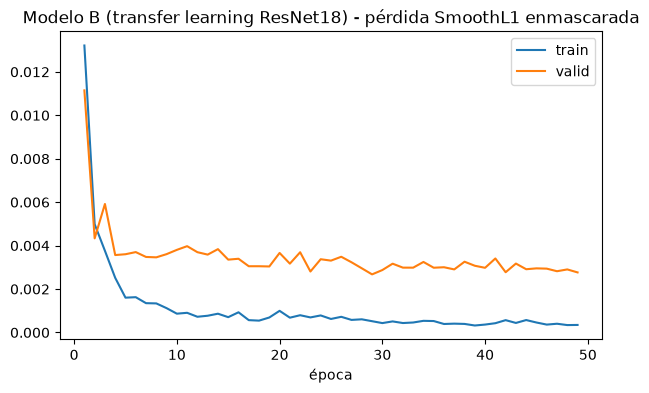

In [13]:

hist_b = pd.DataFrame(history_b, columns=["epoch", "train_loss", "val_loss"])
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(hist_b.epoch, hist_b.train_loss, label="train")
ax.plot(hist_b.epoch, hist_b.val_loss, label="valid")
ax.set_title("Modelo B (transfer learning ResNet18) - pérdida SmoothL1 enmascarada")
ax.set_xlabel("época"); ax.legend()
plt.show()



## Checkpoint 9: Modelo C: YOLO-pose reutilizado

En vez de entrenar un tercer modelo desde cero, se reutiliza el detector YOLO-pose entrenado en `notebooks/actividad_3b_yolo_pose_deteccion.ipynb`. 

Es importante aclarar que a diferencia de los modelos A y B, YOLO no recibe el recorte ya aislado del jugador. YOLO procesa la **imagen completa** y primero tiene que *encontrar* al jugador (bbox) antes de ubicar sus keypoints. Para comparar en el mismo espacio, cada predicción de YOLO sobre una imagen de test se empareja con la instancia real correspondiente por IoU de bbox (>0.3) y se transforma a coordenadas relativas al mismo recorte que
usan los modelos A/B.

In [14]:

from ultralytics import YOLO

with open(PROC / "pose_model_artifact.json") as f:
    pose_artifact = json.load(f)
yolo_model = YOLO(pose_artifact["weights_path"])

def iou_xywhn(b1, b2, W, H):
    def to_xyxy(b):
        cx, cy, w, h = b
        return (cx-w/2)*W, (cy-h/2)*H, (cx+w/2)*W, (cy+h/2)*H
    x1a,y1a,x2a,y2a = to_xyxy(b1); x1b,y1b,x2b,y2b = to_xyxy(b2)
    xi1,yi1 = max(x1a,x1b), max(y1a,y1b)
    xi2,yi2 = min(x2a,x2b), min(y2a,y2b)
    inter = max(0,xi2-xi1)*max(0,yi2-yi1)
    area_a = (x2a-x1a)*(y2a-y1a); area_b = (x2b-x1b)*(y2b-y1b)
    union = area_a+area_b-inter
    return inter/union if union>0 else 0.0

test_df = df[df.split == "test"].reset_index(drop=True)
test_manifest = manifest[manifest.split == "test"].reset_index(drop=True)

from collections import defaultdict
by_image = defaultdict(list)
for idx, r in test_df.iterrows():
    by_image[r.image_path].append((idx, r))

yolo_pred_crop = {}  # idx -> (5,2) array en coords relativas al recorte
n_matched = 0
for image_path, instances in by_image.items():
    result = yolo_model.predict(image_path, imgsz=384, conf=0.15, verbose=False)[0]
    W, H = result.orig_shape[1], result.orig_shape[0]
    preds = []
    if result.boxes is not None and len(result.boxes) > 0:
        boxes_xywhn = result.boxes.xywhn.cpu().numpy()
        kpts_xy = result.keypoints.xy.cpu().numpy()
        preds = list(zip(boxes_xywhn, kpts_xy))
    for idx, r in instances:
        gt_box = (r.cx, r.cy, r.w, r.h)
        best_iou, best_pred = 0.0, None
        for pbox, pkpts in preds:
            iou = iou_xywhn(gt_box, pbox, W, H)
            if iou > best_iou:
                best_iou, best_pred = iou, pkpts
        if best_pred is not None and best_iou > 0.3:
            m_row = test_manifest.iloc[idx]
            cw, ch = m_row.crop_right - m_row.crop_left, m_row.crop_bottom - m_row.crop_top
            crop_rel = np.array([[(px - m_row.crop_left)/cw, (py - m_row.crop_top)/ch] for px, py in best_pred])
            yolo_pred_crop[idx] = crop_rel
            n_matched += 1

print(f"Detecciones de YOLO emparejadas con instancias de test: {n_matched}/{len(test_df)}")


Detecciones de YOLO emparejadas con instancias de test: 218/221



## Checkpoint 10: Comparación de los 3 modelos: error de predicción por keypoint

Error absoluto medio en **píxeles del recorte** (128×192), calculado únicamente sobre los ejes con dato real (máscara=1), para que ningún modelo sea penalizado por ejes que ni siquiera tienen una anotación confiable de referencia.


  keypoint  cnn_propia  transfer_learning  yolo_pose  n_comparaciones
0   hombro        6.36               5.27       4.05              432
1     codo        7.47               5.97       5.09              416
2   muneca        8.55               7.39       5.24              400
3  raqueta       14.85              11.41       9.93              390
4   cabeza        5.89               5.21       4.34              438


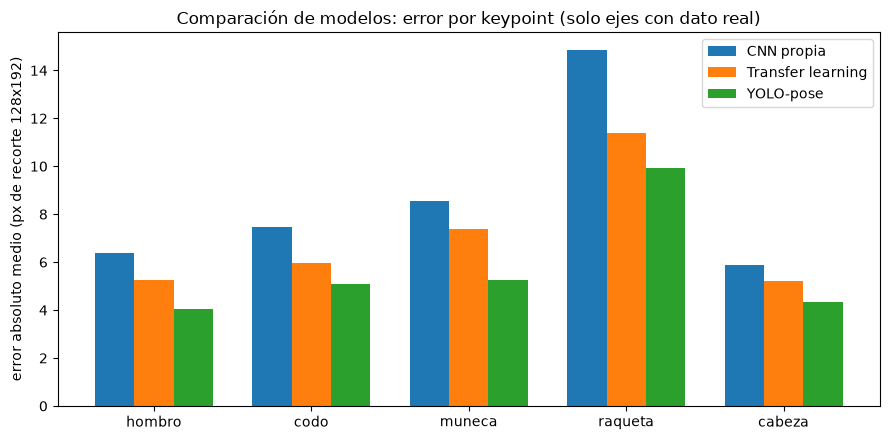

In [15]:

def predict_all(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, kb, mb in loader:
            preds.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(preds, axis=0)

pred_a_test = predict_all(model_a, test_loader_a)
pred_b_test = predict_all(model_b, test_loader_b)

kb_test = test_manifest[KP_COLS].values.astype(np.float32)
mb_test = test_manifest[MASK_COLS].values.astype(np.float32)

def per_keypoint_error(pred, kb, mb, img_size=IMG_SIZE):
    errs = {i: [] for i in range(5)}
    for row_i in range(len(kb)):
        for kp_i in range(5):
            if mb[row_i, 2*kp_i] > 0:
                errs[kp_i].append(abs(pred[row_i,2*kp_i]-kb[row_i,2*kp_i]) * img_size[0])
            if mb[row_i, 2*kp_i+1] > 0:
                errs[kp_i].append(abs(pred[row_i,2*kp_i+1]-kb[row_i,2*kp_i+1]) * img_size[1])
    return errs

errs_a = per_keypoint_error(pred_a_test, kb_test, mb_test)

# modelo B usa el mismo orden de filas que test_manifest (mismo split, sin shuffle)
errs_b = per_keypoint_error(pred_b_test, kb_test, mb_test)

# modelo C (yolo): solo instancias emparejadas
errs_c = {i: [] for i in range(5)}
for idx, crop_rel in yolo_pred_crop.items():
    row = test_manifest.iloc[idx]
    for kp_i in range(5):
        if row[f"mask_{2*kp_i}"] > 0:
            errs_c[kp_i].append(abs(crop_rel[kp_i,0]-row[f"kp_{2*kp_i}"]) * IMG_SIZE[0])
        if row[f"mask_{2*kp_i+1}"] > 0:
            errs_c[kp_i].append(abs(crop_rel[kp_i,1]-row[f"kp_{2*kp_i+1}"]) * IMG_SIZE[1])

comparison_rows = []
for i, name in enumerate(KP_NAMES):
    comparison_rows.append(dict(
        keypoint=name,
        cnn_propia=np.mean(errs_a[i]) if errs_a[i] else np.nan,
        transfer_learning=np.mean(errs_b[i]) if errs_b[i] else np.nan,
        yolo_pose=np.mean(errs_c[i]) if errs_c[i] else np.nan,
        n_comparaciones=len(errs_a[i]),
    ))
comp_df = pd.DataFrame(comparison_rows)
print(comp_df.round(2))

fig, ax = plt.subplots(figsize=(9,4.5))
x = np.arange(5); width=0.25
ax.bar(x-width, comp_df.cnn_propia, width, label="CNN propia")
ax.bar(x, comp_df.transfer_learning, width, label="Transfer learning")
ax.bar(x+width, comp_df.yolo_pose, width, label="YOLO-pose")
ax.set_xticks(x); ax.set_xticklabels(KP_NAMES)
ax.set_ylabel("error absoluto medio (px de recorte 128x192)")
ax.set_title("Comparación de modelos: error por keypoint (solo ejes con dato real)")
ax.legend()
plt.tight_layout()
plt.show()



## Checkpoint 11: Visualización: predicciones vs. valores reales en test

Para varios ejemplos de test se dibuja el esqueleto **real** (verde) contra el **predicho por cada modelo** (Modelo A en azul, Modelo B en rojo), sobre el recorte usado como entrada.


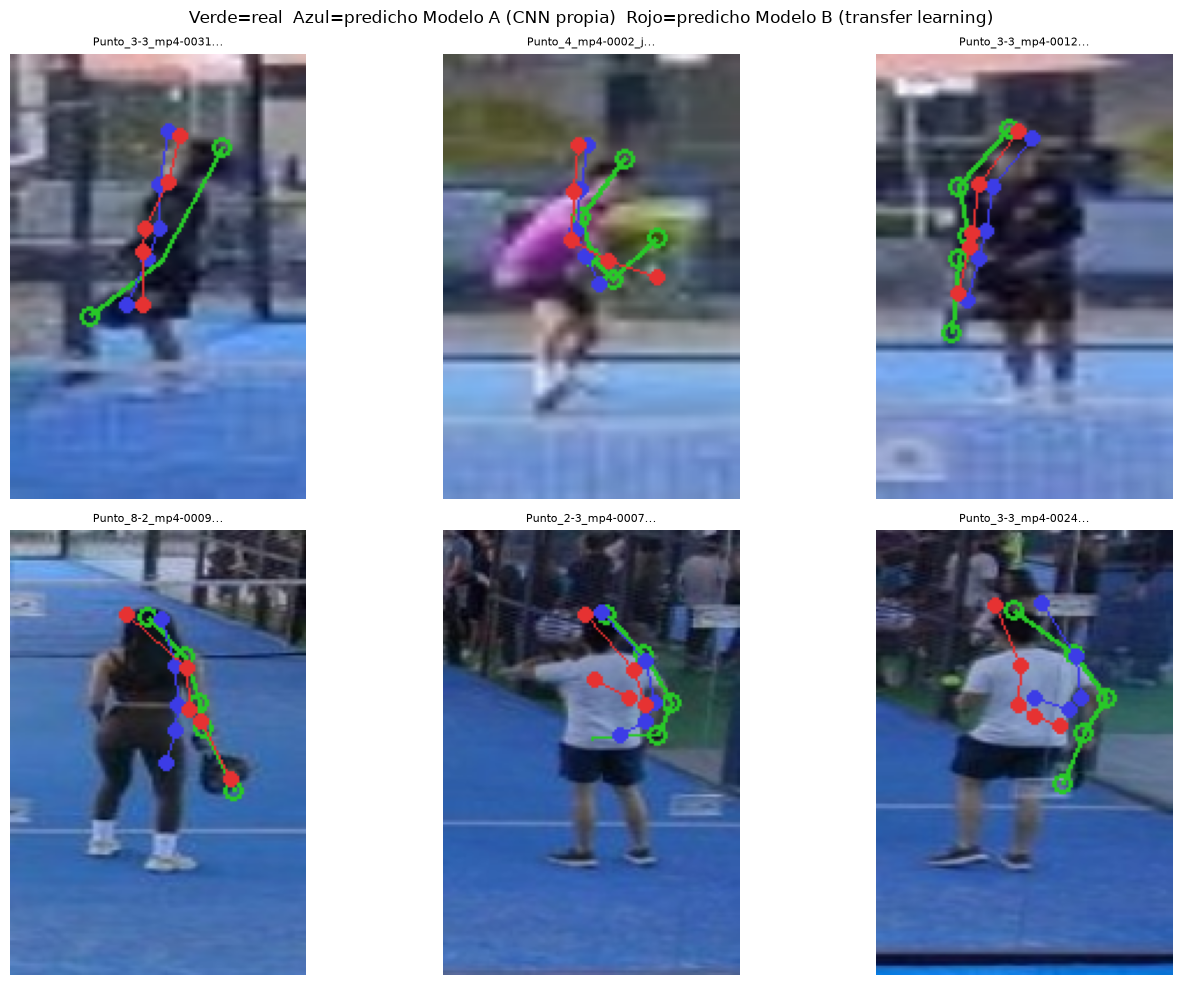

In [16]:

def draw_pred_vs_true(crop_path, true_kp, true_mask, pred_dict, size=IMG_SIZE):
    im = Image.open(crop_path).convert("RGB").resize(size, Image.BILINEAR)
    draw = ImageDraw.Draw(im)
    W, H = size
    SKELETON = [(4,0),(0,1),(1,2),(2,3)]  # cabeza(4)-hombro(0)-codo(1)-muneca(2)-raqueta(3)

    def pts_from(vec):
        return [(vec[2*i]*W, vec[2*i+1]*H) for i in range(5)]

    true_pts = pts_from(true_kp)
    for a, b in SKELETON:
        draw.line([*true_pts[a], *true_pts[b]], fill=(40,200,40), width=2)
    for i,(x,y) in enumerate(true_pts):
        if true_mask[2*i] > 0 and true_mask[2*i+1] > 0:
            draw.ellipse([x-4,y-4,x+4,y+4], outline=(40,200,40), width=2)

    colors = {"Modelo A": (60,60,230), "Modelo B": (230,50,50)}
    for name, vec in pred_dict.items():
        pts = pts_from(vec)
        c = colors.get(name, (255,255,0))
        for a, b in SKELETON:
            draw.line([*pts[a], *pts[b]], fill=c, width=1)
        for (x,y) in pts:
            draw.ellipse([x-3,y-3,x+3,y+3], fill=c)
    return im

rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(test_manifest), size=6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for ax, i in zip(axes.flat, sample_idx):
    row = test_manifest.iloc[i]
    true_kp = row[KP_COLS].values.astype(np.float32)
    true_mask = row[MASK_COLS].values.astype(np.float32)
    pred_dict = {"Modelo A": pred_a_test[i], "Modelo B": pred_b_test[i]}
    im = draw_pred_vs_true(row.crop_path, true_kp, true_mask, pred_dict)
    ax.imshow(im)
    ax.axis("off")
    ax.set_title(f"{row.image_id[:18]}...", fontsize=8)
fig.suptitle("Verde=real  Azul=predicho Modelo A (CNN propia)  Rojo=predicho Modelo B (transfer learning)")
plt.tight_layout()
plt.show()



## Checkpoint 12: Clasificación del tipo de keypoint (cabeza/hombro/codo/muñeca/raqueta)

Acá se hace la clasificación con matriz de confusión.

A diferencia de una clase derivada por una regla geométrica, acá la clase real ya viene dada directamente por la anotación: **qué tipo de keypoint es cada punto**. 

Se recorta un parche pequeño centrado en cada keypoint válido (`v>0`) de las 1150 instancias - 5514 parches en total, bastante balanceados entre las 5 clases (1061-1149 cada una) - y se entrena una CNN de clasificación (5 clases) desde cero sobre esos parches.

El tamaño del parche es **proporcional al alto del bbox de la persona** (`0.5×alto_bbox`, acotado entre 24 y 90 px) en vez de un tamaño fijo, para que un jugador cercano y uno lejano queden encuadrados de forma comparable. 

Se probó primero visualmente: parches de cabeza y raqueta suelen ser reconocibles (pelo/piel vs. objeto delgado sobre fondo), pero hombro y codo muestran texturas de ropa muy similares entre sí. Así que se espera confusión real entre clases vecinas del cuerpo, no un 100% trivial.


In [17]:

PATCH_FRAC, MIN_PATCH, MAX_PATCH = 0.5, 24, 90
KPT_IMG_SIZE = 48

kpt_rows = []
for _, r in df.iterrows():
    for i in range(5):
        if r[f"mask_{2*i}"] > 0:  # v>0 (mask_x == mask_y siempre, ver Checkpoint 3)
            kpt_rows.append(dict(image_path=r.image_path, x=r[f"kp_{2*i}"], y=r[f"kp_{2*i+1}"],
                                  bbox_h=r.h, split=r.split, label=i))

kpt_df = pd.DataFrame(kpt_rows)
print("Total de parches (keypoints válidos):", len(kpt_df))
print(pd.crosstab(kpt_df.split, kpt_df.label).rename(columns=dict(enumerate(KP_NAMES)))[KP_NAMES])

def load_patch(row, W=640, H=640):
    im = Image.open(row.image_path).convert("RGB")
    side = float(np.clip(row.bbox_h * H * PATCH_FRAC, MIN_PATCH, MAX_PATCH))
    px, py = row.x * W, row.y * H
    box = (px - side/2, py - side/2, px + side/2, py + side/2)
    crop = im.crop(box).resize((KPT_IMG_SIZE, KPT_IMG_SIZE), Image.BILINEAR)
    return np.asarray(crop, dtype=np.float32) / 255.0


Total de parches (keypoints válidos): 5514
label  hombro  codo  muneca  raqueta  cabeza
split                                       
test      217   210     201      197     220
train     679   667     648      657     682
valid     236   233     212      208     247


In [18]:
kpt_df.head()

,image_path,x,y,bbox_h,split,label
0,/Users/psychobolt/Documents/education/universi...,0.286939,0.455639,0.1625,train,0
1,/Users/psychobolt/Documents/education/universi...,0.290966,0.476279,0.1625,train,1
2,/Users/psychobolt/Documents/education/universi...,0.298767,0.498430,0.1625,train,2
3,/Users/psychobolt/Documents/education/universi...,0.304163,0.532989,0.1625,train,3
4,/Users/psychobolt/Documents/education/universi...,0.276370,0.428454,0.1625,train,4


### Checkpoint 12.1: Ejemplos de parches por clase

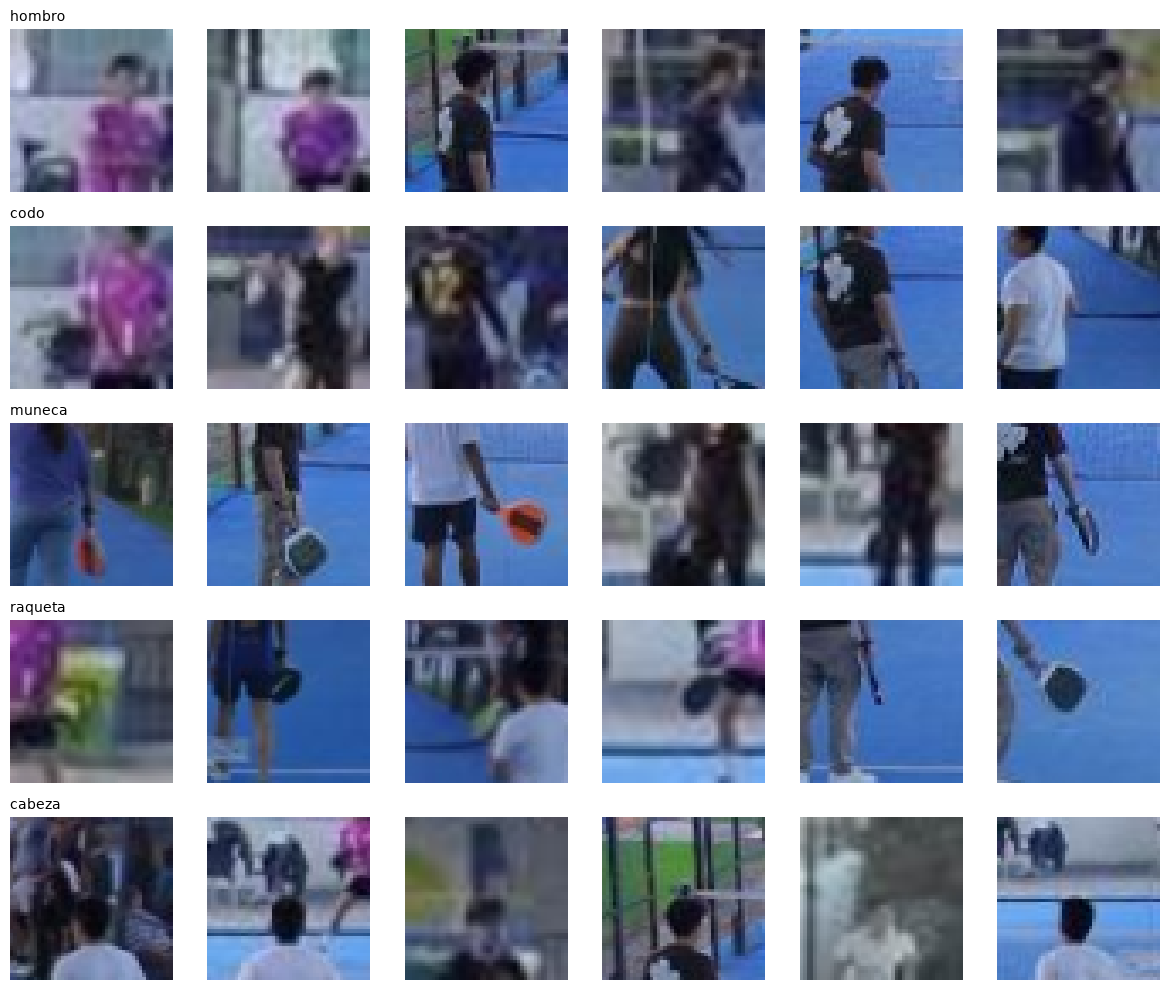

In [19]:

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
rng = np.random.RandomState(SEED)
for ci, name in enumerate(KP_NAMES):
    sub = kpt_df[kpt_df.label == ci]
    sample_idx = rng.choice(len(sub), 6, replace=False)
    for j, si in enumerate(sample_idx):
        row = sub.iloc[si]
        axes[ci, j].imshow(load_patch(row))
        axes[ci, j].axis("off")
        if j == 0:
            axes[ci, j].set_title(name, loc="left", fontsize=10)
plt.tight_layout()
plt.show()



### Checkpoint 12.2: Dataset, CNN y entrenamiento

Normalización con media/desviación calculada solo sobre una muestra de train (mismo criterio que en los modelos de regresión). Arquitectura liviana (parches de solo 48×48 px): 3 bloques
Conv–BatchNorm–ReLU con MaxPool en los dos primeros, GlobalAveragePooling y una capa lineal a 5 clases.


In [20]:

train_kpt = kpt_df[kpt_df.split == "train"].reset_index(drop=True)
sample = train_kpt.sample(min(400, len(train_kpt)), random_state=SEED)
pix = np.stack([load_patch(r) for _, r in sample.iterrows()])
KPT_MEAN = pix.reshape(-1, 3).mean(axis=0)
KPT_STD = pix.reshape(-1, 3).std(axis=0)
print("Media (RGB, train):", KPT_MEAN)
print("Desv. estándar (RGB, train):", KPT_STD)

class PatchDataset(Dataset):
    def __init__(self, d, train=False):
        self.d = d.reset_index(drop=True)
        self.train = train

    def __len__(self):
        return len(self.d)

    def __getitem__(self, i):
        row = self.d.iloc[i]
        arr = load_patch(row)
        if self.train and random.random() < 0.5:
            arr = arr[:, ::-1, :].copy()
        arr = (arr - KPT_MEAN) / (KPT_STD + 1e-6)
        arr = np.transpose(arr, (2, 0, 1)).astype(np.float32)
        return torch.from_numpy(arr), row.label

kpt_train_loader = DataLoader(PatchDataset(kpt_df[kpt_df.split=="train"], True), batch_size=64, shuffle=True)
kpt_valid_loader = DataLoader(PatchDataset(kpt_df[kpt_df.split=="valid"], False), batch_size=64, shuffle=False)
kpt_test_loader = DataLoader(PatchDataset(kpt_df[kpt_df.split=="test"], False), batch_size=64, shuffle=False)

class KptTypeCNN(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(64, n_classes))

    def forward(self, x):
        return self.head(self.features(x))

kpt_model = KptTypeCNN().to(device)
print(kpt_model)
print("Parámetros entrenables:", sum(p.numel() for p in kpt_model.parameters()))

kpt_opt = torch.optim.Adam(kpt_model.parameters(), lr=1e-3)
kpt_crit = nn.CrossEntropyLoss()

def run_epoch_cls(loader, train):
    kpt_model.train(train)
    tot_loss, tot_correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train: kpt_opt.zero_grad()
        out = kpt_model(xb)
        loss = kpt_crit(out, yb)
        if train:
            loss.backward(); kpt_opt.step()
        tot_loss += loss.item() * xb.size(0)
        tot_correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return tot_loss / n, tot_correct / n

# Código original: 25 épocas y selección del mejor modelo por exactitud de validación.
# KPT_EPOCHS = 25
# kpt_history = []
# best_val_acc, best_state = -1, None
# for ep in range(1, KPT_EPOCHS + 1):
#     tr_l, tr_a = run_epoch_cls(kpt_train_loader, True)
#     va_l, va_a = run_epoch_cls(kpt_valid_loader, False)
#     kpt_history.append((ep, tr_l, tr_a, va_l, va_a))
#     if va_a > best_val_acc:
#         best_val_acc = va_a
#         best_state = {k: v.clone() for k, v in kpt_model.state_dict().items()}
#     print(f"ep{ep:02d} train_loss={tr_l:.3f} train_acc={tr_a:.3f}  val_loss={va_l:.3f} val_acc={va_a:.3f}")
# kpt_model.load_state_dict(best_state)

# Cambio para aplicar Early Stopping sobre validation loss y restaurar su mínimo absoluto.
KPT_EPOCHS = 500
KPT_PATIENCE = 20
KPT_MIN_DELTA = 1e-4

kpt_history = []
best_val_loss = float("inf")
best_state = None
best_epoch = None
early_stopping_reference = float("inf")
epochs_without_significant_improvement = 0

for ep in range(1, KPT_EPOCHS + 1):
    tr_l, tr_a = run_epoch_cls(kpt_train_loader, True)
    va_l, va_a = run_epoch_cls(kpt_valid_loader, False)
    kpt_history.append((ep, tr_l, tr_a, va_l, va_a))

    # Implementación anterior: usaba el mínimo absoluto como referencia de min_delta.
    # improvement = best_val_loss - va_l

    # Guardar siempre el mínimo absoluto, aunque la mejora sea menor que min_delta.
    if va_l < best_val_loss:
        best_val_loss = va_l
        best_epoch = ep
        best_state = {k: v.detach().cpu().clone() for k, v in kpt_model.state_dict().items()}

    # Implementación anterior de la paciencia (preservada para referencia).
    # if improvement >= KPT_MIN_DELTA:
    #     epochs_without_significant_improvement = 0
    # else:
    #     epochs_without_significant_improvement += 1

    # Referencia separada: las mejoras pequeñas pueden acumularse hasta min_delta.
    if early_stopping_reference - va_l >= KPT_MIN_DELTA:
        early_stopping_reference = va_l
        epochs_without_significant_improvement = 0
    else:
        epochs_without_significant_improvement += 1

    print(f"ep{ep:03d} train_loss={tr_l:.3f} train_acc={tr_a:.3f}  val_loss={va_l:.3f} val_acc={va_a:.3f}")

    if epochs_without_significant_improvement >= KPT_PATIENCE:
        print(f"Early Stopping activado en la época {ep}: validation loss no mejoró al menos {KPT_MIN_DELTA:.1e} durante {KPT_PATIENCE} épocas.")
        break

if best_state is None:
    raise RuntimeError("No se pudo guardar un estado válido del modelo.")
kpt_model.load_state_dict(best_state)
print(f"Mejor época: {best_epoch} | Mejor validation loss: {best_val_loss:.6f}")


Media (RGB, train): [    0.31221     0.37164     0.48286]
Desv. estándar (RGB, train): [    0.15637     0.16647     0.21775]
KptTypeCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=1)
  )
  (head): Sequential(
    (0): Flatten(start_dim=

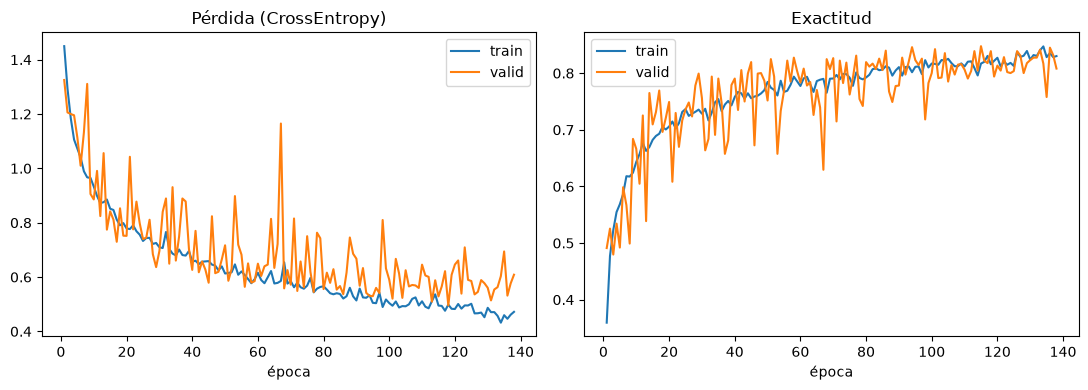

In [21]:

hist_df = pd.DataFrame(kpt_history, columns=["epoch", "train_loss", "train_acc", "val_loss", "val_acc"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_df.epoch, hist_df.train_loss, label="train")
axes[0].plot(hist_df.epoch, hist_df.val_loss, label="valid")
axes[0].set_title("Pérdida (CrossEntropy)"); axes[0].set_xlabel("época"); axes[0].legend()
axes[1].plot(hist_df.epoch, hist_df.train_acc, label="train")
axes[1].plot(hist_df.epoch, hist_df.val_acc, label="valid")
axes[1].set_title("Exactitud"); axes[1].set_xlabel("época"); axes[1].legend()
plt.tight_layout()
plt.show()



### Checkpoint 12.3: Baseline y evaluación en test


Exactitud clasificación tipo-de-keypoint en test — mayoritario: 0.211 | CNN: 0.872


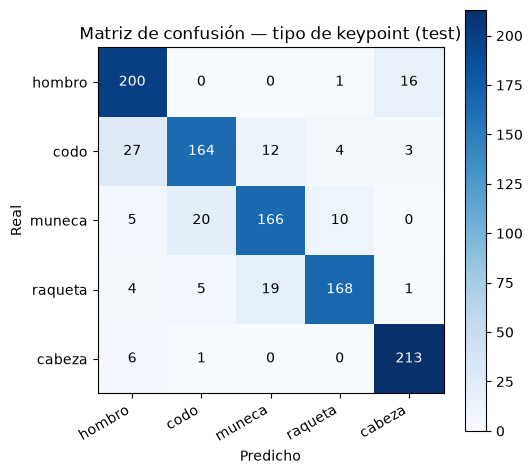


Reporte de clasificación (test):
              precision    recall  f1-score   support

      hombro       0.83      0.92      0.87       217
        codo       0.86      0.78      0.82       210
      muneca       0.84      0.83      0.83       201
     raqueta       0.92      0.85      0.88       197
      cabeza       0.91      0.97      0.94       220

    accuracy                           0.87      1045
   macro avg       0.87      0.87      0.87      1045
weighted avg       0.87      0.87      0.87      1045



In [22]:

maj_label = Counter(kpt_df.loc[kpt_df.split=="train", "label"]).most_common(1)[0][0]
test_kpt = kpt_df[kpt_df.split == "test"]
acc_majority = (test_kpt.label == maj_label).mean()

kpt_model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in kpt_test_loader:
        out = kpt_model(xb.to(device))
        all_pred.extend(out.argmax(1).cpu().tolist())
        all_true.extend(yb.tolist())

acc_test = accuracy_score(all_true, all_pred)
print(f"Exactitud clasificación tipo-de-keypoint en test — mayoritario: {acc_majority:.3f} | CNN: {acc_test:.3f}")

cm = confusion_matrix(all_true, all_pred, labels=list(range(5)))
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(5)); ax.set_xticklabels(KP_NAMES, rotation=30, ha="right")
ax.set_yticks(range(5)); ax.set_yticklabels(KP_NAMES)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — tipo de keypoint (test)")
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

print("\nReporte de clasificación (test):")
print(classification_report(all_true, all_pred, target_names=KP_NAMES))



### Checkpoint 12.4: Análisis visual de errores

Se muestran parches mal clasificados junto con la clase real y la predicha, para relacionar los errores con lo observado en el Checkpoint 12.1 (hombro/codo con texturas de ropa parecidas, raqueta a veces casi invisible sobre el fondo de la cancha).


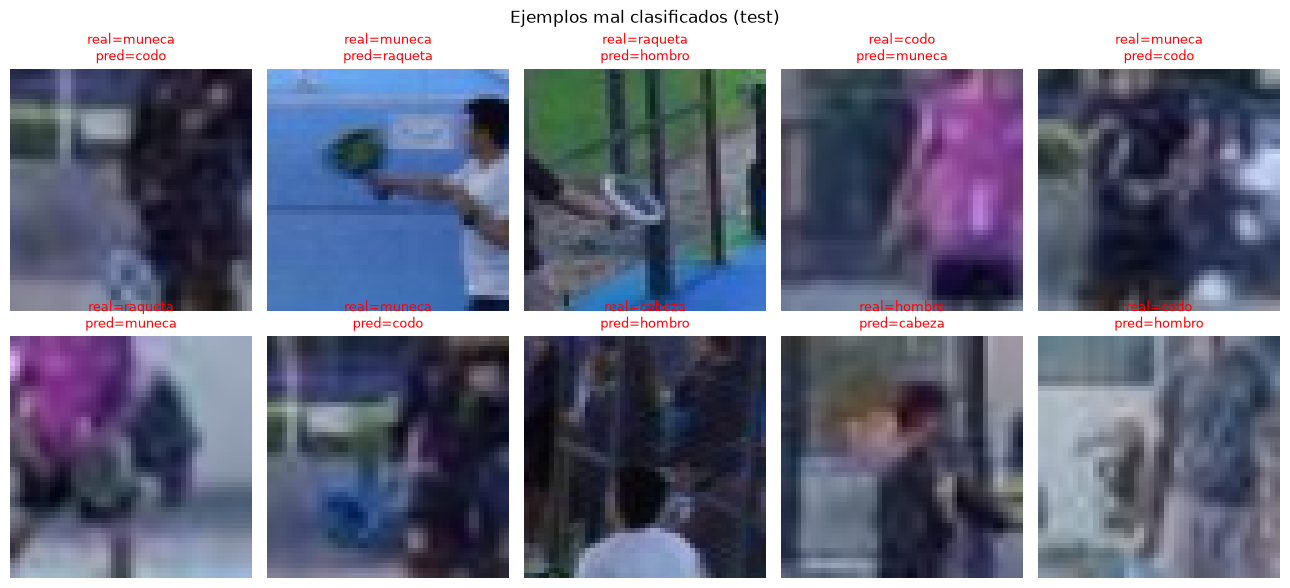

Errores en test: 134 / 1045


In [23]:

test_kpt_r = test_kpt.reset_index(drop=True)
wrong_idx = [i for i in range(len(all_true)) if all_true[i] != all_pred[i]]
show_idx = rng.choice(wrong_idx, min(10, len(wrong_idx)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, i in zip(axes.flat, show_idx):
    row = test_kpt_r.iloc[i]
    ax.imshow(load_patch(row))
    ax.set_title(f"real={KP_NAMES[all_true[i]]}\npred={KP_NAMES[all_pred[i]]}", fontsize=9, color="red")
    ax.axis("off")
plt.suptitle("Ejemplos mal clasificados (test)")
plt.tight_layout()
plt.show()

print(f"Errores en test: {len(wrong_idx)} / {len(all_true)}")



## Checkpoint 13: Limitaciones

- **Tamaño del dataset**: 1150 instancias de solo aprox 35 rallies. Tras particionar por rally, cada split ve poca diversidad de escenarios. Para la clasificación de tipo de keypoint esto se compensa un poco porque cada instancia aporta hasta 5 parches (uno por keypoint válido), dando aprox 5500 muestras en total.

- **Clasificación de tipo de keypoint, no de golpeo**: se abandonó la idea de clasificar la "posición de impacto" a partir de una regla geométrica (`extension`/ángulo), ya que con el dataset corregido esa variable resultó tener un rango real demasiado angosto para ser una clase robusta. En su lugar se clasifica algo con clase verdadera directa (qué keypoint es cada punto), que da un resultado más sólido (aprox 69% en test vs. aprox 20% del azar) pero **no dice nada sobre el tipo de golpe**. para eso, hace falta tratat el golpeo con más datos, o etiquetado manual del tipo de golpe.

- **Tamaño del parche y confusión entre clases vecinas**: el parche (0.5× alto de bbox) para un jugador chico/lejano puede terminar mostrando gran parte del cuerpo en vez de un área puramente local del keypoint, lo que explica la confusión observada entre hombro y codo (texturas de ropa parecidas) y entre cabeza y raqueta en algunos casos. 
Se puede afirmar que un parche de tamaño fijo más chico probablemente reduciría esta confusión a costa de perder contexto quando el jugador está muy lejos de la cámara.

- **Comparación de modelos de regresión con distinto punto de partida**: Con YOLO-pose se resuelve la tarea de encontrar al jugador en la imagen completa, en vez de solo ubicar keypoints en un recorte ya aislado, y el emparejamiento por IoU con la instancia real puede introducir ruido adicional en la comparación.
